Running Load Dynamics Simulation...


100%|██████████| 4000/4000 [00:11<00:00, 360.58it/s]


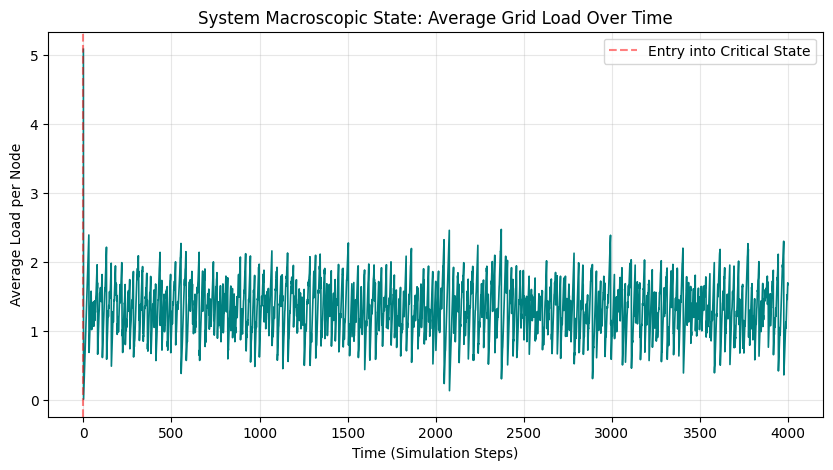

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def analyze_load_dynamics(NUM_NODES=1000, RADIUS=0.05, TOL=0.20, NOISE=0.8, STEPS=4000):
    G = nx.random_geometric_graph(NUM_NODES, radius=RADIUS)

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    average_loads = []

    print("Running Load Dynamics Simulation...")
    for step in tqdm(range(STEPS)):
        current_total_load = 0

        # Add noise
        for node in G.nodes():
            G.nodes[node]['load'] += (NOISE / 10.0)

        # Cascade
        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True

                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs: G.nodes[nbr]['load'] += spill

        # Calculate mean load of surviving nodes (or total grid)
        # Here we calculate average load of all nodes (tripped are 0)
        loads = [G.nodes[n]['load'] for n in G.nodes()]
        average_loads.append(np.mean(loads))

        for node in G.nodes(): G.nodes[node]['tripped'] = False

    return average_loads

# --- PLOTTING ---
avg_loads = analyze_load_dynamics()

plt.figure(figsize=(10, 5))
plt.plot(avg_loads, color='teal', linewidth=1.2)
plt.title("System Macroscopic State: Average Grid Load Over Time")
plt.xlabel("Time (Simulation Steps)")
plt.ylabel("Average Load per Node")
plt.axvline(x=avg_loads.index(max(avg_loads[:1000])), color='red', linestyle='--', alpha=0.5, label="Entry into Critical State")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()